### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [151]:
import warnings
warnings.filterwarnings("ignore")
import sklearn as sk
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster



**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [49]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign (1).csv


In [97]:
df_raw = pd.read_csv("marketing_campaign.csv", sep='\t')
df = df_raw.copy()

In [98]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [100]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Пропущено 24 значення у колонці 'Income'. Це незначна кількість, тому немає сенсу її видаляти.

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

Заповнювати краще медіаною, тому що вона стійка до викидів і не впливатиме на центр кластерів.

In [101]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [102]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Видно, що тепер немає пропусків в результаті заповнення медіаною.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [104]:
# delete 'id' column
df = df.drop('ID', axis = 1)

In [105]:
# convert str to datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [106]:
# create 'Custumer_Years' column
reference_year = df['Dt_Customer'].dt.year.max()
df['Customer_Years'] = reference_year - df['Dt_Customer'].dt.year

In [107]:
# create a new column 'Customer_Month' - when person became a client
df['Customer_Month'] = df['Dt_Customer'].dt.month

In [108]:
# convert year of birth to 'age join'
df['Age_at_join'] = df['Dt_Customer'].dt.year - df['Year_Birth']

In [109]:
# one-hot encoding
df = pd.get_dummies(df, columns = ['Education', 'Marital_Status'], dtype = int)

In [110]:
# delete columns
df = df.drop(['Dt_Customer', 'Year_Birth'], axis = 1)

In [111]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,0,0,1,0,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,0,0,1,0,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,0,0,0,0,1,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,0,0,0,0,1,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,1,0,0,0,1,0,0,0,0


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [117]:
# features for clustering
X = df.drop([
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
], axis = 1)

In [118]:
# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [119]:
kmeans = KMeans(n_clusters = 3, n_init = 'auto', random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [121]:
labels = kmeans.predict(X_scaled)
print(labels)

[2 0 2 ... 2 1 0]


In [124]:
df['Cluster'] = labels

In [125]:
score = silhouette_score(X_scaled, labels)
print("Silhouette score: ", score)

Silhouette score:  0.11558863167783842


Результат метрики Силует приблизно 0.116, що значить, що розбиття на 3 кластери замало, KMeans не знайшов чіткі групи.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [131]:
# visualization
fig = px.scatter_3d(
    df,
    x = 'Income',
    y = 'NumStorePurchases',
    z = 'NumWebPurchases',
    color = 'Cluster',
    title = 'Customer Clusters by Income and Purchase Behavior'
)
fig.show()

На графіку не видно груп кластерів - вони нечітко розділені. Видно, що є викиди. Візуалізація відповідає результату метрики, де також не виявлено кластерної структури.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

NB: Я у попередньому пункті одразу робила з масштабуванням, тому тут виконаю без, щоб не переписувати.

In [132]:
kmeans = KMeans(n_clusters=3, n_init='auto', random_state = 42)
labels_no_scale = kmeans.fit_predict(X)

score_no_scale = silhouette_score(X, labels_no_scale)
print('Silhouette no scaling: ', score_no_scale)

Silhouette no scaling:  0.5383702542342631


Без масштабування вийшов кращий результат. У даному випадку масшабування погіршило роботу моделі. Тому попередню обробку даних треба перепровіряти, а не робити за замовченням.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [136]:
# remove outliers based on income
threshold = 200000
df_no_outliers = df[df['Income'] < threshold]
print('Original shape:', df.shape)
print('Without outliers:', df_no_outliers.shape)

Original shape: (2240, 41)
Without outliers: (2239, 41)


Для видалення викидів застосовано поріг у 200.000, у результаті видалено викид на 600.000.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

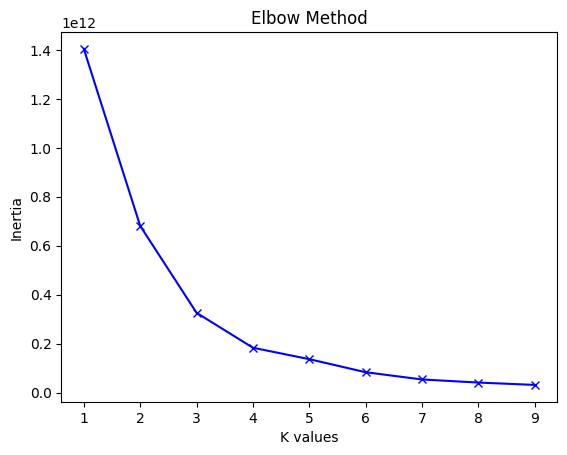

In [142]:
K = range(1, 10)
sum_of_squared_distances = []

for k in K:
  model = KMeans(n_clusters = k, n_init = 'auto').fit(X)
  sum_of_squared_distances.append(model.inertia_)


plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()




Для немасштабованих даних, згідно методу Ліктя, оптимальне число кластерів 3.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [144]:
# features for clustering
X_hier = df_no_outliers.drop([
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
], axis = 1)

In [146]:
# single linkage
Z = linkage(X_hier, method='single')

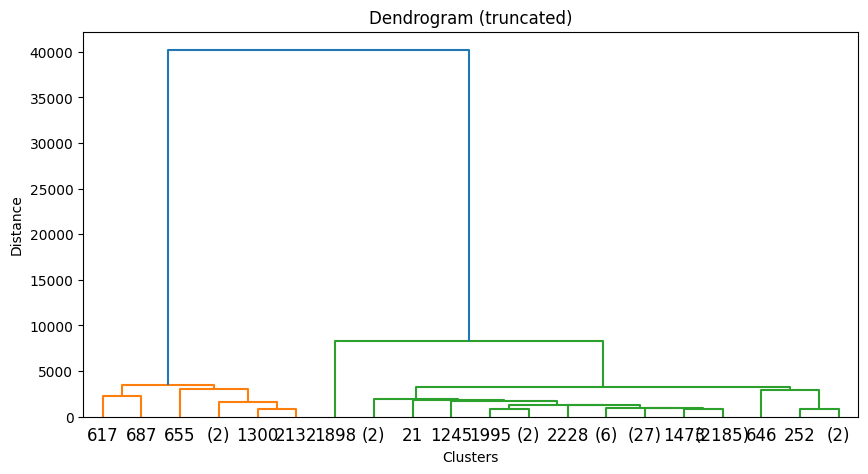

In [147]:
# dendrogram
plt.figure(figsize=(10, 5))

dendrogram(
    Z,
    truncate_mode = 'lastp',
    p = 20
)

plt.title('Dendrogram (truncated)')
plt.xlabel('Clusters')
plt.ylabel('Distance')
plt.show()

In [148]:
# 2 clusters
labels_2 = fcluster(Z, t = 2, criterion = 'maxclust')

In [149]:
labels_3 = fcluster(Z, t = 3, criterion = 'maxclust')

In [150]:
# silhouette
score_2 = silhouette_score(X_hier, labels_2)
score_3 = silhouette_score(X_hier, labels_3)
print('Silhouette (2 clusters): ', score_2)
print('Silhouette (3 clusters): ', score_3)

Silhouette (2 clusters):  0.765791712227693
Silhouette (3 clusters):  0.5585669643077911


На основі дендрограми та метрики силуету, оптимальна кількість кластерів 2. Цей результат кращий за KMeans, де було 3 кластери.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [154]:
# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)


In [155]:
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)


print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 17
Number of noise points: 2089


In [156]:
# silhouette
without_noise = labels_db != -1
silhouette_score(X_scaled[without_noise], labels_db[without_noise])

np.float64(0.3488903160632566)

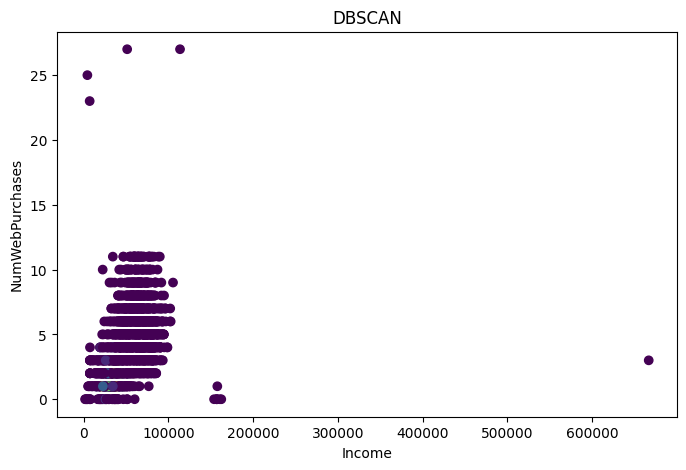

In [159]:
# visualization
plt.figure(figsize=(8, 5))
plt.scatter(df['Income'], df['NumWebPurchases'], c=labels_db)
plt.title('DBSCAN')
plt.xlabel('Income')
plt.ylabel('NumWebPurchases')
plt.show()

DBSCAN не виявив значущих кластерів, більшість покупок в одній групі, де дохід у межах 100.000 та незначна кількість покупок. Видно викид, де дохід перевищує 600.000, а також подекуди висока кількість покупок (23 +). Даний підхід виявився неефективним для цієї задачі.